# TODO

- nearest neighbor query
- model selection (1, 5, 10, 15, 20 neighbors)

In [1]:
import numpy as np
import pickle

from pathlib import Path
from itertools import product
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer, SimpleImputer
from numpy.lib.stride_tricks import sliding_window_view

from aipad.pad_imputation import (
    make_train_test, form_test_matrices,
    plot_results, read_npzs, save_results
)
from aipad.spacecrafts import SoloConstants, WindConstants

solo = SoloConstants()
wind = WindConstants()

In [2]:
bin_width_deg = 1
time_avg_min = 1
avg_bin_dir = f"{time_avg_min}min_{bin_width_deg}deg"

load_path = Path("./data/intensities") / avg_bin_dir
cov_path = Path("./data/coverages") / avg_bin_dir
plot_path = Path(f"./plots/")
model_path = Path("./data/models")

plot_path.mkdir(exist_ok=True)
model_path.mkdir(exist_ok=True)

In [3]:
# Train test split: pick e.g. every 3rd as test (train, train, test, train, train, test...)
# Events are in time order so this takes the solar cycle into account.
# NOTE: using future observations to predict past observations is generally not OK, but
# the nature of the data is such that this can be ignored.

hist_arr, reduced_hist_arr, intensity_arr, metadata_arr = read_npzs(load_path=load_path)

X_train, X_test, y_train, y_test, I_train, I_test, meta_train, meta_test = make_train_test(hist_arr, reduced_hist_arr, intensity_arr, metadata_arr, n=3)

# Stacking of training cases for KNN imputer:
# concatenate 5 successive rows to one feature vector (5 * 180 = 900 features)
trains = []
for train in X_train:
    train_stacked = sliding_window_view(train, window_shape=(5,180)).reshape(-1, 5 * train.shape[1])   # ChatGPT solution
    trains.append(train_stacked)

X_train_stacked = np.vstack(trains)

### Mean value imputation
Two ways to do this with either rows as samples or columns as samples. `SimpleImputer()` uses mean of column as the value to fill.

TODO/Ideas:
- Dividing into smaller chunks probably makes it better (in both cases), since then the variations over large scales don't affect the local mean

In [ ]:
# fitting to test cases since "fitting" is just calculating the means of each column. "Supervised learning" approach is not applicable here
# Columns as samples: each time bin is filled with the mean across the whole angle space.
for j in range(0, len(y_test)):
    model = SimpleImputer(keep_empty_features=True) 
    res = form_test_matrices(model, X_test[j], y_test[j], transpose=True)
    plot_results(model, res, I_test[j], sc=wind, cov_sc=solo, save_path=Path("./plots") / "meanimputer" / f"results_{j}_columns-as-samples.png")

/home/ojsant/miniconda3/envs/aipad/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/ojsant/miniconda3/envs/aipad/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/ojsant/miniconda3/envs/aipad/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/ojsant/miniconda3/envs/aipad/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/ojsant/miniconda3/envs/aipad/lib/python3.13/site-packages/sklearn/metrics/_regress

### KNNImputer

In [ ]:
neighbors = 5

model = KNNImputer(n_neighbors=neighbors, weights="distance", keep_empty_features=True)
model.fit(X_train_stacked)
dump_file = open(model_path / f'knnimputer_20250111', 'wb')
pickle.dump(model, dump_file)
dump_file.close()

In [ ]:
for j in range(0, len(y_test)):
    res = form_test_matrices(model, X_test[j], y_test[j])
    plot_results(model, res, "mse", I_test[j], sc=wind, cov_sc=solo, save_path=plot_path / f"results_{j}.png")

ValueError: x and y must have same first dimension, but have shapes (144,) and (720,)

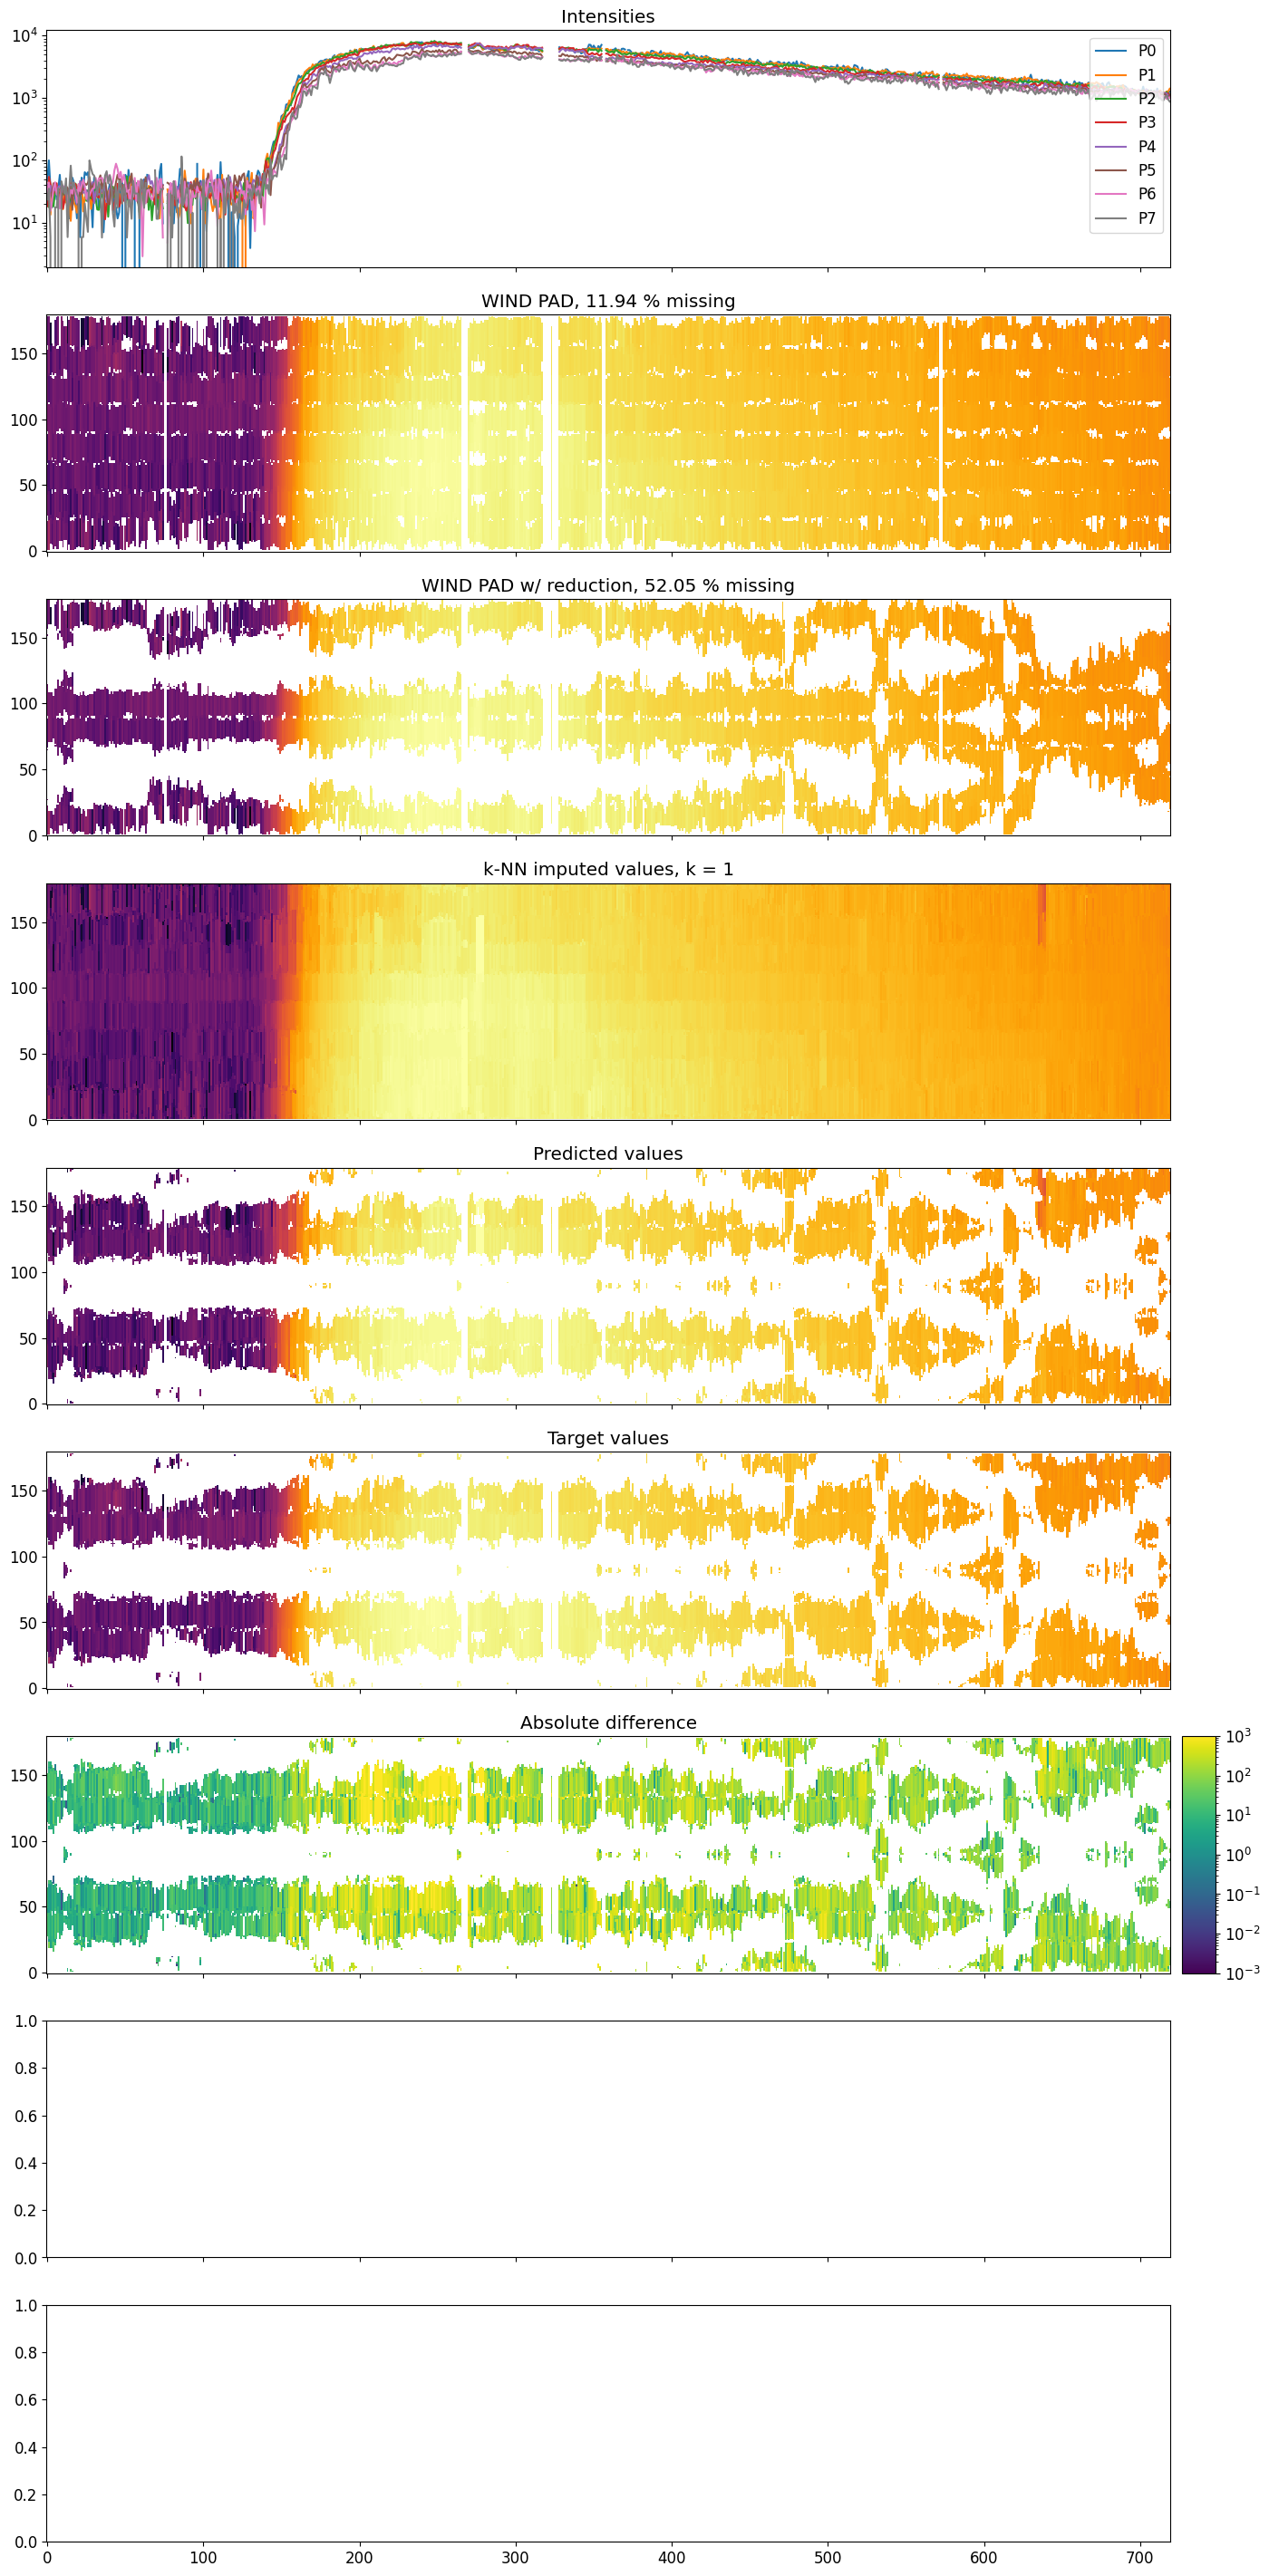

In [4]:
# Model selection
neighbors = [1, 5, 10, 15]
weights = ["distance", "uniform"]
n_to_test = 3
# Cross validation: shift train-test split by one 3 times (a sort of 3-fold CV),
# but test only 5 first events in each fold
for shift in range(n_to_test):
    (X_train, X_test, y_train, y_test,
     I_train, I_test, meta_train, meta_test) = make_train_test(hist_arr, reduced_hist_arr,
                                                               intensity_arr, metadata_arr,
                                                               n=n_to_test, shift=shift)
    trains = []
    for train in X_train:
        train_stacked = sliding_window_view(train, window_shape=(5,180)).reshape(-1, 5 * train.shape[1])   # ChatGPT solution
        trains.append(train_stacked)

    X_train_stacked = np.vstack(trains)

    for n, w in product(neighbors, weights):
        model = KNNImputer(n_neighbors=n, weights=w, keep_empty_features=True)
        model.fit(X_train_stacked)
        
        for j in range(5):
            res = form_test_matrices(model, X_test[j], y_test[j])
            plot_results(model, res, "mse", I_test[j], sc=wind, cov_sc=solo,
                         save_path=plot_path / "knnimputer" / f"{time_avg_min}min_{bin_width_deg}deg" / f"results_{j}.png")
            save_results(model, res, metadata_arr, "mse", Path("./knnimputer_results.csv"))